# UM4MA379, Statistique Computationnelle, 2025-2026

Sorbonne Université, Master 1

Cours :  A. Guyader<br>
TP : M. Sangnier

## TP 1 : Simulation Monte-Carlo

# Table of contents
1. [Exercice 1 : Lien géométrique/exponentielle](#part1)
1. [Exercice 2 : Nul n'est censé ignorer la loi normale ](#part2)
1. [Exercice 3: Monte-Carlo standard versus échantillonnage préférentiel ](#part3)
1. [Exercice 4 : Here comes trouble](#part4)


In [1]:
import numpy as np  # Vectors and matrices
from scipy import stats  # Probability distributions
import matplotlib.pyplot as plt  # Plots

# Enable nice plots
import matplotlib as mpl
try:
    mpl.style.use('seaborn-v0_8')
except:
    mpl.style.use('seaborn')
mpl.rcParams['image.cmap'] = 'plasma'
nice_hist = dict(bins='auto', density=True, ec='w')

# Exercice 1 : Lien géométrique/exponentielle <a id="part1"></a>
>Soient $0<p<1$ et $X \sim \text{Geo}_{\mathbb N^*}(p)$.
>
>**Question 1.** Soit $p=1/3$. Grâce à la classe `geom` du module `stats`, générer un échantillon de grande taille $n$ et chronométrer la durée d'exécution (on pourra utiliser la fonction `perf_counter` du module `time`).

In [2]:
# Answer
from time import perf_counter

p = 1/3
geo = stats.geom(p=p)
n = 10**8

t0 = perf_counter()

X = geo.rvs(size=n)

print('Durée (s) :', perf_counter()-t0)

Durée (s) : 2.441075020997232


>**Question 2.** Soit $(B_k)_{k\geq 1}$ une suite de variables i.i.d. selon une loi de Bernoulli $\text{Ber}(p)$. Comment obtenir une variable $X$ de loi géométrique $\text{Geo}_{\mathbb N^*}(p)$ à partir de celles-ci ? Implémenter cette méthode. Que se passe-t-il lorsque $p$ est proche de 0 ?

**Réponse :** Avec la convention adoptée, si $(B_k)_{k\geq 1}$ est une suite de variables i.i.d. selon une loi de Bernoulli $\text{Ber}(p)$, alors la variable aléatoire $X:=\min\{k\geq 1,\ B_k=1\}$ suit une loi géométrique de paramètre $p$. Par ailleurs, il est clair que si $p$ est proche de 0, cette méthode est très lente puisqu'il faut en moyenne simuler $1/p$ variables de Bernoulli pour avoir une réalisation de la variable géométrique.

In [4]:
# Answer
ber = stats.bernoulli(p)

B, X = 0, 0
while B==0:
    B = ber.rvs()
    X += 1
        
print(X)

1


>**Question 3.** Soit $p=1/3$. Implémenter la méthode précédente pour générer un échantillon de grande taille $n$, chronométrer la durée d'exécution et comparer à la question 1.

**Réponse :** Cette méthode est bien entendu bien plus lente que la méthode implémentée par défaut.

In [5]:
# Answer
n = 10**5

t0 = perf_counter()

X = np.zeros(n)
for i in range(n):
    B = 0
    while B==0:
        B = ber.rvs()
        X[i] += 1
            
print('Durée (s) :', perf_counter()-t0)

Durée (s) : 4.202427232998161


>**Question 4.** Soient $\lambda>0$, $T \sim \text{Exp}(\lambda)$
>et $X=\lceil T\rceil$ la partie entière par excès de $T$ (i.e. $\lceil 0.4\rceil =1$ et $\lceil 2\rceil =2$). Quelles valeurs peut prendre $X$ ? Avec quelles probabilités ? En déduire un moyen de générer une loi géométrique $\text{Geo}_{\mathbb N^*}(p)$. 

**Réponse :** Un calcul élémentaire montre que si $T \sim \text{Exp}(\lambda)$, alors $X:=\lceil T\rceil\sim\text{Geo}_{\mathbb N^*}(1-e^{-\lambda})$. En effet, $X$ est bien à valeurs dans $\mathbb{N}^\star$ et, pour tout $k\in\mathbb{N}^\star$,
$$\mathbb{P}(X=k)=\mathbb{P}(k-1<T\leq k)=e^{-\lambda(k-1)}-e^{-\lambda k}=\left(1-e^{-\lambda}\right)e^{-\lambda(k-1)}.$$
Autrement dit, si $T \sim \text{Exp}(-\log(1-p))$, alors $X \sim \text{Geo}_{\mathbb N^*}(p)$. On en déduit que pour simuler une loi géométrique, il suffit de seuiller une loi exponentielle.

>**Question 5.** Soit $p=1/3$. Implémenter la méthode précédente pour générer un échantillon de grande taille $n$, chronométrer la durée d'exécution et comparer à la question 1. Que constatez-vous ?

**Réponse :** Cette méthode est en fait un peu plus rapide que celle implémentée dans la fonction `geom` du module `stats`.

In [7]:
# Answer
dist = stats.expon(-1/np.log(1-p))

n = 10**8

t0 = perf_counter()

Xbis = np.ceil(dist.rvs(size=n))

print('Durée (s) :', perf_counter()-t0)

Durée (s) : 1.402610528999503


>**Question 6.** Que donne la méthode d'inversion ?

**Réponse :** Puisque $X$ est à valeurs dans $\mathbb{N}^\star$ avec $\mathbb{P}(X=n)=p_n=p(1-p)^{n-1}$, l'inverse généralisée de sa fonction de répartition s'écrit d'après le cours, pour tout $u\in]0,1]$ :
$$F^{-1}(u)=\sum_{n=1}^\infty n\ \mathbf{1}_{p_1+\dots+p_{n-1}<u\leq p_1+\dots+p_{n}}=\sum_{n=1}^\infty n\ \mathbf{1}_{1-(1-p)^{n-1}<u\leq 1-(1-p)^{n}}.$$
La méthode d'inversion assure que, si $U$ suit une loi uniforme sur $[0,1]$, la variable $X=F^{-1}(U)$ suit une lui géométrique de paramètre $p$. Or, d'après ce qui vient d'être dit, 
$$X=F^{-1}(U)\ \Longleftrightarrow\ 1-(1-p)^{X-1}<U\leq 1-(1-p)^{X}\ \Longleftrightarrow\ X=\left\lceil\frac{\log(1-U)}{\log(1-p)}\right\rceil, $$
et puisque la variable $(\log(1-U))/(\log(1-p))$ suit une loi exponentielle de paramètre $-\log(1-p)$, on retrouve exactement la méthode de seuillage d'une loi exponentielle vue précédemment.

# Exercice 2 : Nul n'est censé ignorer la loi normale  <a id="part2"></a>


>**Question 1.**
Soit $(U,V)$ un couple de variables i.i.d. de loi uniforme sur $[0,1]$. Montrer que les variables $X$ et $Y$ définies par
$$\left\{ \begin{array}{l}
           X=\sqrt{-2\log U}\times\cos(2\pi V)\\
           Y=\sqrt{-2\log U}\times\sin(2\pi V)\\
          \end {array}\right .$$
sont i.i.d. gaussiennes centrées réduites.

**Réponse :** 
On applique la méthode de la fonction muette.
Soit donc $h:\mathbb{R}^2\to\mathbb{R}$ une fonction test (par exemple continue bornée), alors le Théorème de Transfert implique :
\begin{align*}
  \mathbb{E}\left[h(X,Y)\right]
  &= \mathbb{E}\left[h\left(\sqrt{-2\log U}\cos(2\pi V),\sqrt{-2\log U}\sin(2\pi V)\right)\right] \\
  &= \iint_{]0,1[^2}h\left(\sqrt{-2\log u}\cos(2\pi v),\sqrt{-2\log u}\sin(2\pi v)\right) \, dudv.
\end{align*}
L'application $\varphi:(u,v)\mapsto (\sqrt{-2\log u}\cos(2\pi v),\sqrt{-2\log u}\sin(2\pi v))$ est clairement une bijection $\mathcal C^1$ de $]0,1[^2$ dans $\mathbb{R}^2$ (à des ensembles de mesure nulle près) et son jacobien vaut,
pour tout $(u, v) \in ]0, 1[^2$:
$$
  \det( J_{\varphi}(u,v) )
  = \left|
  \begin{array}{cc}
    \frac{-\cos(2\pi v)}{u\sqrt{-2\log u}} & -2\pi\sqrt{-2\log u}\sin(2\pi v)\\
    \frac{-\sin(2\pi v)}{u\sqrt{-2\log u}} & +2\pi\sqrt{-2\log u}\cos(2\pi v)
  \end{array}
  \right|
  = - \frac{2\pi}{u} \neq 0.
$$
C'est donc bien un $\mathcal C^1$-difféomorphisme et l'on peut appliquer le théorème de changement de variables (en notant $(x, y) = \varphi(u, v)$) :
$$
  \mathbb{E}\left[h(X,Y)\right]
%       = \iint_{\mathbb{R}^2}h(x,y)\left|\det(J_{\varphi^{-1}}(x,y))\right| \, dxdy
  = \iint_{\mathbb{R}^2}h(x,y)\frac{1}{\left|\det(J_{\varphi}(\varphi^{-1}(x,y)))\right|} \, dxdy,
$$
avec
$$
  \frac{1}{\left|\det(J_{\varphi}(\varphi^{-1}(x,y)))\right|} = \frac{1}{2\pi}e^{-\frac{x^2+y^2}{2}},
$$
puisque $\frac{1}{| \det( J_{\varphi}(u,v) ) |} = \frac{u}{2\pi}$ et $u = e^{-\frac{x^2+y^2}{2}}$.
Cela donne au final :
$$
  \mathbb{E}\left[h(X,Y)\right]
  = \iint_{\mathbb{R}^2} h(x,y) \frac{1}{2\pi}e^{-\frac{x^2+y^2}{2}} \, dxdy,
$$
et montre que les variables $X$ et $Y$ sont bien i.i.d. gaussiennes centrées réduites.

 >**Question 2.** Algorithme de Box-Muller : estimer le temps nécessaire pour simuler $n=10^7$  gaussiennes avec la méthode de la question précédente. Le comparer à celui mis par la fonction `norm` du module `stats`.

**Réponse :** Les durées sont comparables.

In [8]:
# Answer
n = 10**7
t0 = perf_counter()
R = np.sqrt(-2*np.log(stats.uniform.rvs(size=n//2))) 
theta = 2*np.pi*stats.uniform.rvs(size=n//2)
X = np.concatenate((R*np.cos(theta), R*np.sin(theta)))
print('Durée Box-Muller (s) :', perf_counter()-t0)

t0 = perf_counter()
Xbis = stats.norm.rvs(size=n)
print('Durée stats.norm (s) :', perf_counter()-t0)

Durée Box-Muller (s) : 0.2531049860008352
Durée stats.norm (s) : 0.15176118799718097


>**Question 3.**
Déterminer la loi du couple de variables aléatoires $(W, Z) = \left( \sqrt{U} \cos(2 \pi V), \sqrt{U} \sin(2 \pi V) \right)$.
Comment peut-on simuler cette loi par méthode du rejet ?

**Réponse :**
L'application $\varphi : (u, v) \in ]0, 1]^2 \mapsto \left( \sqrt{u} \cos(2 \pi v), \sqrt{u} \sin(2 \pi v) \right) \in \mathcal D$, où $\mathcal D$ est le disque unité privé de son centre, est un $C^1$-difféomorphisme, de jacobien $\pi$ (informellement, le changement de variable $(w, z) = \varphi(u, v)$ aboutit donc à $dwdz = \pi \, dudv$).
Ainsi, pour toute fonction $h : \mathbb R^2 \to \mathbb R$ continue bornée,
$$
    \mathbb{E}\left[h(W, Z)\right]
    = \iint_{]0, 1]^2} h \left( \sqrt{u} \cos(2 \pi v), \sqrt{u} \sin(2 \pi v) \right) \, dudv
    = \iint_{\mathcal D} h(w, z) \frac 1 \pi \, dwdz.
$$
Ceci montre que $(W, Z)$ est uniformément distribué sur $\mathcal D$.

**Remarque :**
Cela revient à déterminer la loi du couple de variables aléatoires $(W, Z) = \left( \frac{X}{\sqrt{X^2+Y^2}} e^{-\frac{X^2+Y^2}{4}}, \frac{Y}{\sqrt{X^2+Y^2}} e^{-\frac{X^2+Y^2}{4}} \right)$.
Alternativement, en prenant $\boldsymbol \theta \sim \mathcal U([0, 2\pi])$ indépendant de $R$ de densité $r \mapsto r e^{- \frac{r^2}{2}} \mathbf 1_{\mathbb R_+}(r)$, on peut aussi considérer le couple $(W, Z) = \left( \cos(\boldsymbol \theta) e^{- \frac{R^2}{4}}, \sin(\boldsymbol \theta) e^{- \frac{R^2}{4}} \right)$.

**Réponse :**
La densité de la loi que l'on cherche à échantillonner est $f : (w, z) \mapsto \frac{1}{\pi} \mathbb 1_{(w, z) \in \mathcal D}$.
Considérons la loi uniforme sur $[-1, 1]^2$, de densité $g : (w, z) \mapsto \frac{1}{4} \mathbb 1_{(w, z) \in [-1, 1]^2}$.
Nous avons bien $f \le m g$, avec $m = \frac{4}{\pi}$, donc l'algorithme du rejet nous assure que $Z_\tau \sim \mathcal U(\mathcal D)$ lorsque
$(Z_n)_{n \ge 1}$ est i.i.d. selon $\mathcal U([0, 1]^2)$ et
$$
    \tau = \inf \left\{ i \in \mathbb N^\star, r(Z_i) \ge T_i \quad (\star) \right\},
$$
où
1. $(T_n)_{n \ge 1}$ est i.i.d. selon $\mathcal U([0, 1])$ et indépendant de $(Z_n)_{n \ge 1}$ ;
1. $r(z) = \frac{f(z)}{m g(z)} = \frac{\mathbb 1_{z \in \mathcal D}}{\mathbb 1_{z \in [-1, 1]^2}}, \forall z \in \mathbb R^2$ (avec la possibilité de prendre la valeur $\infty$).
Dans notre cas, $r(Z_i) = \mathbb 1_{Z_i \in \mathcal D}$ presque sûrement et le critère $(\star)$ est alors équivalent à $Z_i \in \mathcal D$ presque sûrement.

Autrement dit, l'algorithme du rejet revient à échantillonner sur le carré $[-1, 1]^2$ puis à conserver uniquement les points tombant à l'intérieur du disque unité.

Taille de l'échantillon : 1542


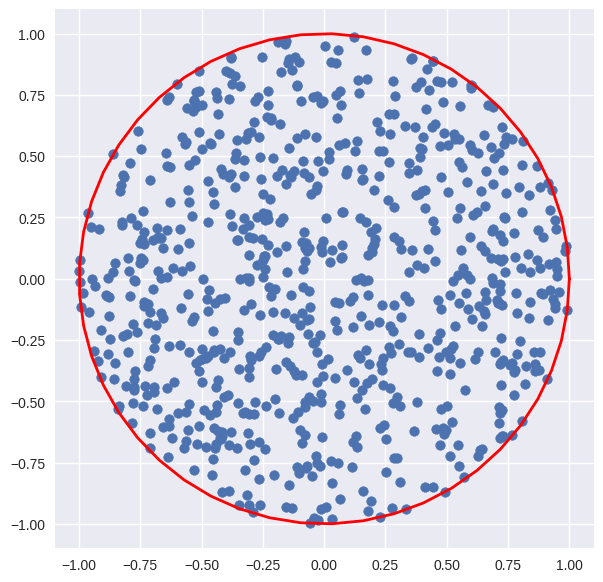

In [9]:
# Answer
n = 10**3

unif = stats.uniform(loc=-1, scale=2)
z = unif.rvs(size=(2, n))
s = np.sum(z**2, axis=0)
z = z[:, np.logical_and(0 < s, s <= 1)]
print("Taille de l'échantillon :", z.size)

t = np.linspace(0, 2*np.pi, num=50)

plt.figure(figsize=(7, 7))
plt.scatter(z[0], z[1])
plt.plot(np.cos(t), np.sin(t), 'r', lw=2)
plt.axis('image');

>**Question 4.**
Méthode polaire de Marsaglia : déduire de la question précédente une nouvelle méthode de simulation de la loi $\mathcal N(0, 1)$.
Quel est son avantage par rapport à l'algorithme de Box-Muller.
Quel est son défaut ?

**Réponse :**
Par construction,
\begin{cases}
    X &= \sqrt{-2\log U} \cos(2\pi V) = \sqrt{-2\log U} \frac{W}{\sqrt U} = \sqrt{-2\log(W^2+Z^2)} \frac{W}{\sqrt{W^2+Z^2}}\\
    Y &= \sqrt{-2\log U} \sin(2\pi V) = \sqrt{-2\log U} \frac{Z}{\sqrt U} = \sqrt{-2\log(W^2+Z^2)} \frac{Z}{\sqrt{W^2+Z^2}}.
\end{cases}
Pour échantillonner $(W, Z)$ sur $\mathcal D$, il suffit d'appliquer la méthode du rejet comme vu à la question précédente.
D'où le code de simulation suivant.

L'avantage de la méthode polaire est de s'affranchir des calculs de cosinus et sinus (qui sont relativement coûteux) : en effet, le point $\left(\frac{W}{\sqrt{W^2+Z^2}}, \frac{Z}{\sqrt{W^2+Z^2}} \right)$ est sur le cercle unité, ainsi ses coordonnées peuvent naturellement être interprétées par $(\cos \theta, \sin \theta)$.
Le défaut de cette approche est d'utiliser une méthode de rejet mais en réalité, on rejette relativement peu : en moyenne environ un point sur 5 (précisément une proportion égale à $1-\pi/4\approx 0,21$).

Taille de l'échantillon : 10000000
Durée méthode polaire (s) : 0.4009235029989213


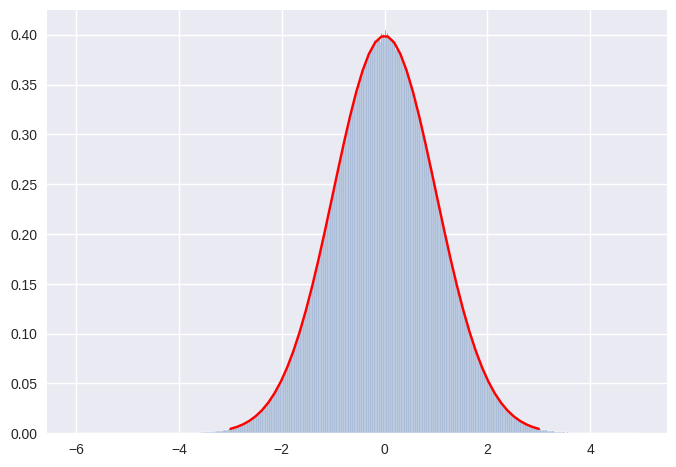

In [10]:
# Answer
n = 10**7

t0 = perf_counter()
unif = stats.uniform(loc=-1, scale=2)
z = unif.rvs(size=(2, int(n/2*1.5)))
s = np.sum(z**2, axis=0)
z = z[:, np.logical_and(0 < s, s <= 1)][:, :n//2]
print("Taille de l'échantillon :", z.size)

s = np.sum(z**2, axis=0)
X = (np.sqrt(-2*np.log(s)) * z / np.sqrt(s)).ravel()
print('Durée méthode polaire (s) :', perf_counter()-t0)

norm = stats.norm()
x = np.linspace(-3, 3)
plt.hist(X, **nice_hist)
plt.plot(x, norm.pdf(x), 'r-');

>**Question 5.** Simuler et représenter $n=1000$ réalisations d'une loi normale multivariée ${\cal N}(m,\Gamma)$ avec
$$m=\left[\begin{array}{l}
2\\
1\end{array}\right]\hspace{1cm}\mbox{et}\hspace{1cm}\Gamma=\left[\begin{array}{ll}
1&1\\
1&4\end{array}\right].$$
Retrouver approximativement $m$ et $\Gamma$ à partir de cet échantillon.

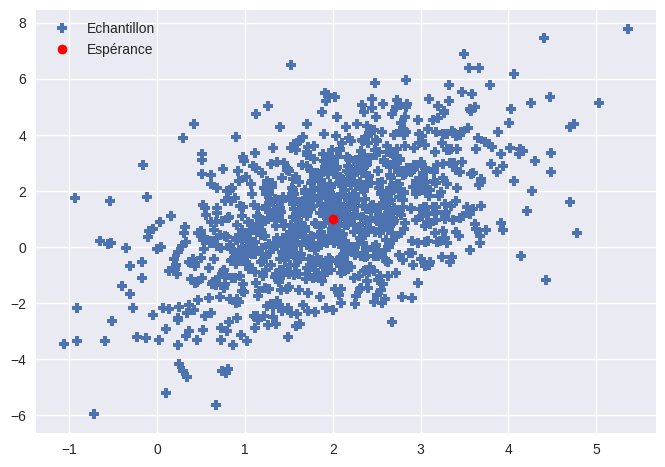

In [11]:
# Answer
n = 10**3
m = [2,1]
Gamma = [[1,1],[1,4]]

x, y = stats.multivariate_normal.rvs(size=n,mean=m, cov=Gamma).T
plt.plot(x, y, 'P', label="Echantillon")
plt.plot(*m ,'o', color="red", label="Espérance")
plt.legend();

In [12]:
# Answer
print("Moyenne empirique :", x.mean(),y.mean())
print("Matrice de covariance empirique :", np.cov(x,y))

Moyenne empirique : 1.9658315713916494 1.062946053426205
Matrice de covariance empirique : [[1.02227446 1.05670295]
 [1.05670295 4.19194713]]


# Exercice 3: Monte-Carlo standard versus échantillonnage préférentiel  <a id="part3"></a>
>On veut retrouver par simulation la valeur de $p=\mathbb{P}(X\geq 6)$ avec $X\sim{\cal N}(0,1)$.
>
>**Question 1.** Déterminer $p$ grâce à la classe `norm` de `scipy.stats`.

In [13]:
# Answer
norm = stats.norm()

threshold = 6

# Compléter
p = 1 - norm.cdf(threshold)
# Fin compléter

print('p =', p)

p = 9.865877004244794e-10


>**Question 2.** Estimer $p$ via l'estimateur Monte-Carlo standard basé sur la simulation de $n$ variables gaussiennes avec $n$ le plus grand possible.

**Réponse :** Les valeurs de $n$ pour lesquelles on peut simuler en un temps raisonnable $n$ v.a. $X_i$ i.i.d. selon une loi normale standard (c'est-à-dire $n$ de l'ordre de $10^8$) aboutissent à un estimateur égal à 0 la plupart du temps.

In [14]:
# Answer
n = 10**8  # int(1e8)

# Compléter
X = norm.rvs(size=n)
estMC = (X >= threshold).mean()
# Fin compléter

print('Estimateur Monte-Carlo standard :', estMC)

Estimateur Monte-Carlo standard : 0.0


>**Question 3.** Si $T \sim \text{Exp}(1)$, donner la densité de l'exponentielle translatée $Y = 6+T$.
>En déduire un estimateur d'échantillonnage préférentiel pour $p$, ainsi qu'un intervalle de confiance asymptotiques à 95% pour $n=500$.

**Réponse :** La variable $Y$ a pour densité 
$$g(y)=e^{-(y-6)}\mathbf{1}_{y>6}.$$
En notant $f$ la densité d'une gaussienne standard, on a bien
$$g(y)=0\ \Longrightarrow\ f(y)\mathbf{1}_{y>6}=0.$$
En notant $(Y_i)_{1\leq i\leq n}$ un échantillon i.i.d. selon la loi exponentielle translatée, un estimateur par échantillonnage préférentiel s'écrit donc
$$\hat p_n=\frac{1}{n}\sum_{i=1}^n\frac{f(Y_i)}{g(Y_i)}\mathbf{1}_{Y_i>6}=\frac{1}{n}\sum_{i=1}^n\frac{f(Y_i)}{g(Y_i)},$$
la dernière égalité venant du fait que les $Y_i$ simulés sont tous supérieurs à 6.

Par la loi des grands nombres, $\hat p_n$ tend presque sûrement vers $p$. De plus, le Théorème Central Limite donne
$$\sqrt{n}\left(\hat p_n-p\right)\xrightarrow[n\to\infty]{\mathcal{L}}\mathcal{N}(0,\sigma^2),$$
avec
$$\sigma^2=\mathbb{V}\left(\frac{f(Y)}{g(Y)}\mathbf{1}_{Y>6}\right).$$
Cette variance asymptotique peut être estimée de manière consistante à partir du même échantillon $(Y_i)_{1\leq i\leq n}$ grâce à la variance empirique 
$$\hat\sigma_n^2=\frac{1}{n}\sum_{i=1}^n\left(\frac{f(Y_i)}{g(Y_i)}\right)^2-\hat p_n^2$$
et le Lemme de Slutsky permet d'affirmer que
$$\sqrt{n}\frac{\hat p_n-p}{\hat\sigma_n}\xrightarrow[n\to\infty]{\mathcal{L}}\mathcal{N}(0,1),$$
d'où des intervalles de confiance de niveau asymptotique $(1-\alpha)$ pour $p$ :
$$\left[\hat p_n-\frac{\Phi^{-1}(1-\alpha/2)\hat\sigma_n}{\sqrt{n}}\ ;\ \hat p_n+\frac{\Phi^{-1}(1-\alpha/2)\hat\sigma_n}{\sqrt{n}}\right].$$

In [15]:
# Answer
exp = stats.expon(loc=threshold)
level = 0.05
n = 500

# Compléter
x = exp.rvs(size=n)
ratio = norm.pdf(x) / exp.pdf(x)
est = ratio.mean()
ic_bound = np.sqrt(((ratio**2).mean() - est**2) / n) * norm.ppf(1-level/2)
# Fin compléter

print(f"Estimateur : {est:1.2e}")
print(f"Intervalle de confiance asymptotique : [{est-ic_bound:1.2e},{est+ic_bound:1.2e}]")

Estimateur : 9.33e-10
Intervalle de confiance asymptotique : [8.01e-10,1.06e-09]


>**Question 4.** Tracer l'évolution de l'estimateur et des intervalles de confiance pour $n$ allant par exemple de 1 à 500.

**Remarque :** Le code qui suit donne l'évolution de l'estimateur et des intervalles de confiance. Bien entendu, comme ce sont des intervalles de confiance asymptotiques, ceux-ci n'ont aucun sens lorsque $n$ est petit. Ce phénomène se reflète d'ailleurs sur la figure puisqu'on voit que ces intervalles se stabilisent dès que $n$ devient supérieur à 100 environ.

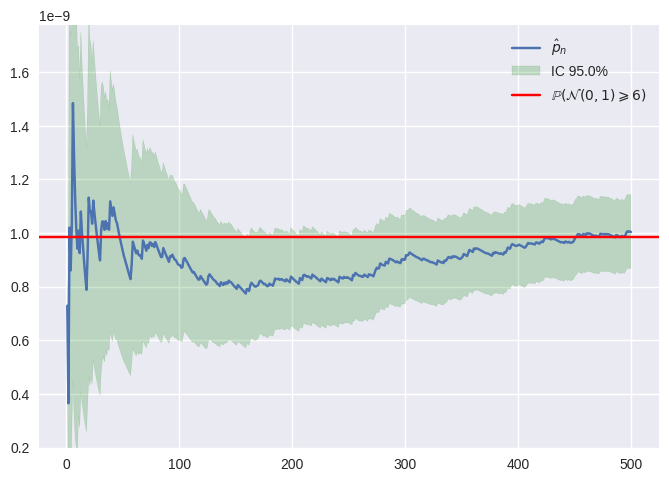

In [16]:
# Answer
exp = stats.expon(loc=threshold)
level = 0.05
n = 500

# Compléter
x = exp.rvs(size=n)
ratio = norm.pdf(x) / exp.pdf(x)

n_range = np.arange(1, n+1)
est = ratio.cumsum() / n_range
ic_bound = np.sqrt(((ratio**2).cumsum() / n_range - est**2) / n_range) * norm.ppf(1-level/2)
std_exp = ic_bound[-1] * np.sqrt(n) / norm.ppf(1-level/2)
# Fin compléter

fig = plt.figure()
plt.plot(n_range, est, label="$\\hat{{p}}_n$")
plt.fill_between(n_range, est+ic_bound, est-ic_bound, color='green', alpha=0.2, label=f"IC {100*(1-level)}%")
plt.axhline(1 - norm.cdf(threshold), color='red', label=f"$\\mathbb{{P}}(\\mathcal{{N}}(0, 1) \\geqslant {threshold})$")
plt.ylim(.2*p, 1.8*p)
plt.legend();

Exemple :

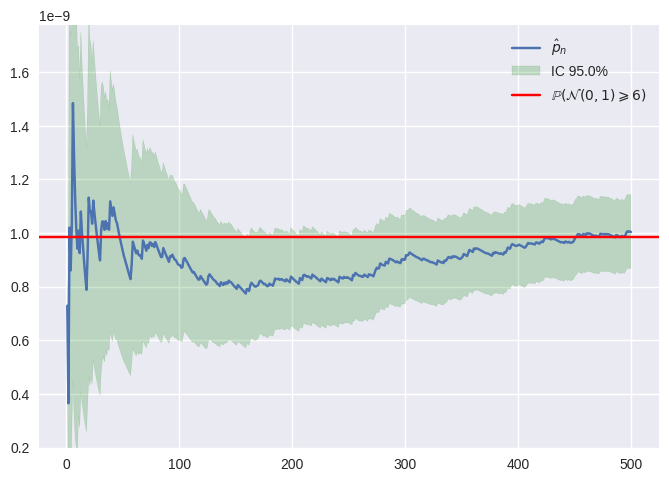

In [17]:
fig

>**Question 5.** Faire de même en considérant pour loi d'échantillonnage une loi gaussienne $Y\sim\mathcal{N}(6,1)$.

**Réponse :** Cette fois, il faut garder l'indicatrice, car lorsque $Y\sim\mathcal{N}(6,1)$, il n'y a en moyenne qu'une chance sur deux pour que $Y$ soit plus grand que 6, et de ce fait contribue à l'estimateur.

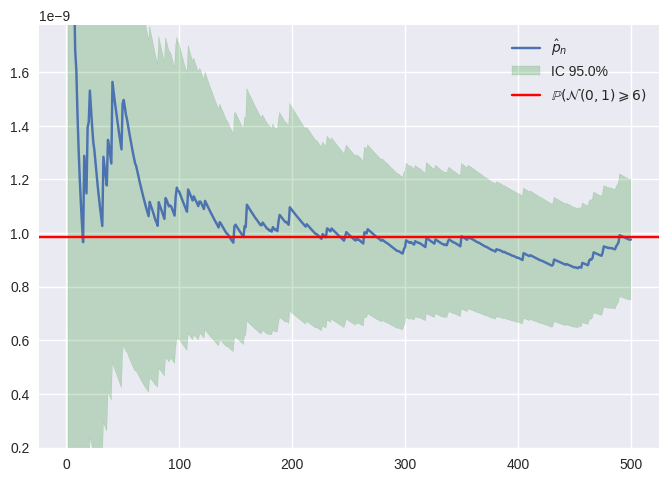

In [18]:
# Answer
aux = stats.norm(loc=threshold)

x = aux.rvs(size=n)
ratio = norm.pdf(x) * (x>=6) / aux.pdf(x)

est2 = ratio.cumsum() / n_range
ic_bound = np.sqrt(((ratio**2).cumsum() / n_range - est2**2) / n_range) * norm.ppf(1-level/2)
std_gauss = ic_bound[-1] * np.sqrt(n) / norm.ppf(1-level/2)

plt.plot(n_range, est2, label="$\\hat{{p}}_n$")
plt.fill_between(n_range, est2+ic_bound, est2-ic_bound, color='green', alpha=0.2, label=f"IC {100*(1-level)}%")
plt.axhline(1 - norm.cdf(threshold), color='red', label=f"$\\mathbb{{P}}(\\mathcal{{N}}(0, 1) \\geqslant {threshold})$")
plt.ylim(.2*p, 1.8*p)
plt.legend();

>**Question 6.** Des deux dernières méthodes, laquelle choisissez-vous ?

**Réponse :** Les deux estimateurs étant asymptotiquement normaux, on choisit celui qui a le plus petit écart-type asymptotique. Puisqu'on dispose d'estimateurs consistants pour ceux-ci, tout le travail a déjà été fait.

In [19]:
# Answer
print(f"Estimateur de l'écart-type asymptotique, cas exponentiel : {std_exp:1.2e}")
print(f"Estimateur de l'écart-type asymptotique, cas gaussien    : {std_gauss:1.2e}")

Estimateur de l'écart-type asymptotique, cas exponentiel : 1.56e-09
Estimateur de l'écart-type asymptotique, cas gaussien    : 2.56e-09


# Exercice 4 : Here comes trouble <a id="part4"></a>
>On veut retrouver par simulation la valeur de $p=\mathbb{P}(X\geq 10)$ avec $X$ qui suit une loi de Pareto de paramètres $(1,3)$, c'est-à-dire de densité $f(x)=3 x^{-4}\mathbf{1}_{x\geq 1}$.
>
>**Question 1.** Déterminer la valeur de $p$ par le calcul.

**Réponse :** La densité de la loi en question est $f : x \in \mathbb R \mapsto \frac{3}{x^4} \mathbb 1_{x \ge 1}$.
Le calcul est donc immédiat :
$$p=\int_{10}^{+\infty}f(x)\,dx=\left[-x^{-3}\right]_{10}^{+\infty}=10^{-3}.$$

>**Question 2.** Proposer une méthode de simulation par inversion pour simuler suivant cette loi de Pareto.

**Réponse :** La fonction de répartition de la loi de Pareto est, pour tout $x \in \mathbb R$ :
$$
    F(x)
    = \int_{-\infty}^{x} f(t)\,dt
    = \left[-t^{-3}\right]_{1}^{x} \mathbb 1_{x \ge 1}
    = \left(1 - \frac{1}{x^3} \right) \mathbb 1_{x \ge 1}.
$$
On obtient donc, pour tout $u \in [0, 1[$ :
$$
    F^{-1}(u) = \frac{1}{(1-u)^{1/3}},
$$
et, pour une variable aléatoire $U \sim \mathcal U([0, 1])$, $F^{-1}(U)$ suit une loi de Pareto de paramètres $(1, 3)$.

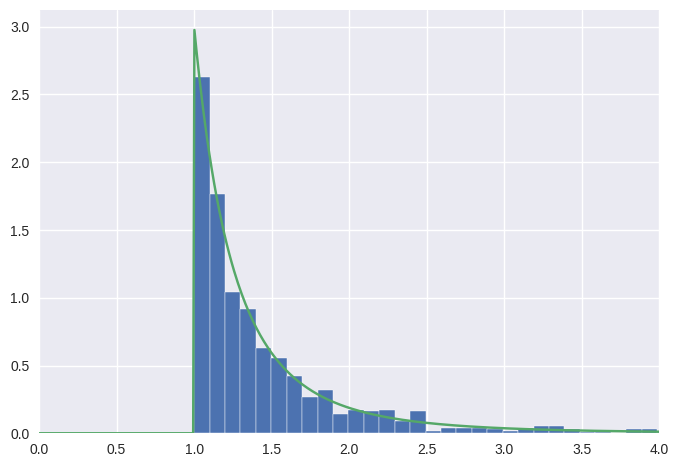

In [20]:
# Answer
unif = stats.uniform()
pareto = stats.pareto(b=3)

n = 1000

# Compléter
u = unif.rvs(size=n)
x = 1 / (1-u)**(1/3)
# Fin compléter

t = np.linspace(0, 4, num=500)
plt.hist(x, label='Échantillon', **nice_hist)
plt.plot(t, pareto.pdf(t), label='Densité')
plt.xlim((0, t.max()));

>**Question 3.** Illustrer la convergence de l'estimateur Monte-Carlo standard, ainsi que les intervalles de confiance asymptotiques à 95% (on pourra utiliser le simulateur de la question précédente ou `stats.pareto`).

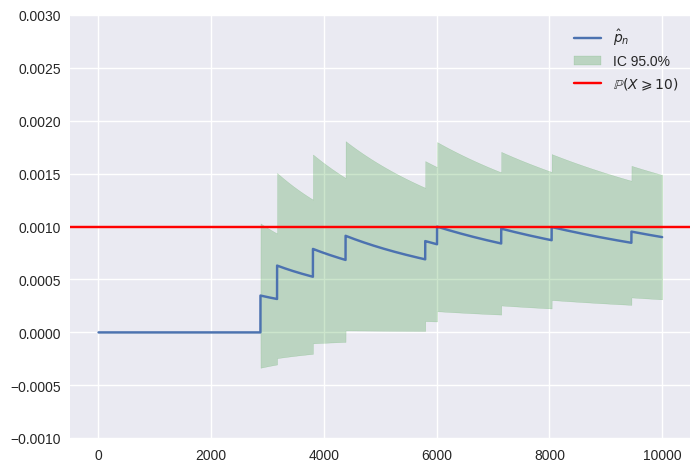

In [21]:
# Answer
threshold = 10
level = 0.05

norm = stats.norm()
pareto = stats.pareto(b=3)

p = 1 - pareto.cdf(threshold)

n = 10000
x = pareto.rvs(size=n)

n_range = np.arange(1, n+1)
est = (x>=threshold).cumsum() / n_range
ic_bound = np.sqrt((est * (1-est)) / n_range) * norm.ppf(1-level/2)

plt.plot(n_range, est, label="$\\hat{{p}}_n$")
plt.fill_between(n_range, est+ic_bound, est-ic_bound, color='green', alpha=0.2, label=f"IC {100*(1-level)}%")
plt.axhline(p, color='red', label=f"$\\mathbb{{P}}(X \\geqslant {threshold})$")
plt.ylim(-p, 3*p)
plt.legend();

>**Question 4.** Utiliser une loi exponentielle translatée pour estimer $p$ par échantillonnage préférentiel, représenter la convergence, les intervalles de confiance, et expliquer ce qui se passe.

**Réponse :** Si on utilise une loi exponentielle translatée pour estimer $p$ par échantillonnage préférentiel, on voit sur la simulation ci-après que les intervalles de confiance sont complètement instables. Ceci est dû au fait que, en notant $f$ la densité de la loi d'origine (Pareto) et $g$ celle de la loi instrumentale (exponentielle), l'hypothèse 
$$\mathbb{V}\left(\frac{f(Y)}{g(Y)}\mathbf{1}_{Y>10}\right)<\infty$$ 
n'est pas vérifiée dans ce contexte :
$$\mathbb{E}\left[\left(\frac{f(Y)}{g(Y)}\mathbf{1}_{Y>10}\right)^2\right]=\int_{10}^\infty\left(\frac{3y^{-4}}{e^{-(y-10)}}\right)^2e^{-(y-10)}dy=\int_{10}^\infty9y^{-8}e^{y-10}dy=+\infty.$$
Dit simplement, la loi exponentielle est à queue de distribution plus légère que la loi de Pareto, ce qui explique les sauts dans l'estimateur par échantillonnage préférentiel : dès que $Y_i$ prend une "grande valeur", le rapport $f(Y_i)/g(Y_i)=3Y_i^{-4}\exp(Y_i-10)$ explose. Morale de l'histoire : pour la méthode d'importance sampling, il ne faut pas prendre comme loi instrumentale (i.e. celle de $Y$) une loi à queue plus légère que la loi d'origine (i.e. celle de $X$) si l'on veut une précision (i.e. des intervalles de confiance) sur le résultat !

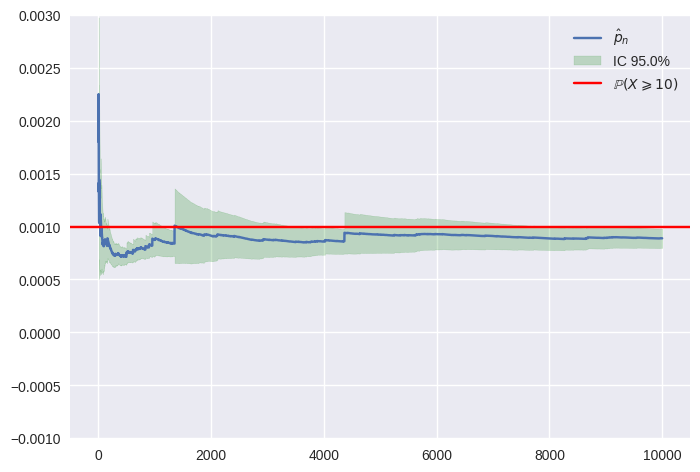

In [22]:
# Answer
aux = stats.expon(loc=threshold)

x = aux.rvs(size=n)
ratio = pareto.pdf(x) / aux.pdf(x)

est = ratio.cumsum() / n_range
ic_bound = np.sqrt(((ratio**2).cumsum() / n_range - est**2) / n_range) * norm.ppf(1-level/2)

plt.plot(n_range, est, label="$\\hat{{p}}_n$")
plt.fill_between(n_range, est+ic_bound, est-ic_bound, color='green', alpha=0.2, label=f"IC {100*(1-level)}%")
plt.axhline(p, color='red', label=f"$\\mathbb{{P}}(X \\geqslant {threshold})$")
plt.ylim(-p, 3*p)
plt.legend();